# Proyek Klasifikasi Gambar: Rice Image Dataset

- **Nama:** Rafli Ardiansyah  
- **Email:** rrapliard@gmail.com  
- **ID Dicoding:** mikachuu



## Import Semua Packages/Library yang Digunakan

In [4]:
!pip install -q kagglehub

import kagglehub
import os
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

### Data Loading


In [5]:
dataset_path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")

dataset_path = Path(dataset_path)
print("Dataset path:", dataset_path)
print("Files:", os.listdir(dataset_path))

Using Colab cache for faster access to the 'rice-image-dataset' dataset.
Dataset path: /kaggle/input/rice-image-dataset
Files: ['Rice_Image_Dataset']


In [6]:
# Download dataset dari Kaggle
DATASET_SLUG = "muratkokludataset/rice-image-dataset"
DOWNLOAD_DIR = Path("/content/dataset")
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

if not any(DOWNLOAD_DIR.iterdir()):
    !kaggle datasets download -d muratkokludataset/rice-image-dataset -p /content/dataset --unzip
else:
    print("Dataset folder already exists. Skip download.")

print("Isi folder dataset:")
for item in DOWNLOAD_DIR.iterdir():
    print("-", item)

Dataset URL: https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset
License(s): CC0-1.0
100% 219M/219M [00:06<00:00, 35.9MB/s]

Isi folder dataset:
- /content/dataset/Rice_Image_Dataset


In [7]:
# Cari folder root yang berisi folder kelas gambar.
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images_in_dir(directory):
    return sum(1 for f in Path(directory).iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS)

def find_class_root(base_dir):
    base_dir = Path(base_dir)
    candidates = []
    for root, dirs, files in os.walk(base_dir):
        root = Path(root)
        class_dirs = []
        for d in dirs:
            d_path = root / d
            if count_images_in_dir(d_path) > 0:
                class_dirs.append(d_path)
        if len(class_dirs) >= 2:
            candidates.append((root, class_dirs))
    if not candidates:
        raise FileNotFoundError("Tidak menemukan folder kelas gambar di dataset.")
    # Pilih kandidat dengan jumlah folder kelas terbanyak.
    candidates = sorted(candidates, key=lambda x: len(x[1]), reverse=True)
    return candidates[0]

DATA_ROOT, CLASS_DIRS = find_class_root(DOWNLOAD_DIR)
class_names = sorted([p.name for p in CLASS_DIRS])
num_classes = len(class_names)

print("Data root:", DATA_ROOT)
print("Class names:", class_names)
print("Number of classes:", num_classes)

Data root: /content/dataset/Rice_Image_Dataset
Class names: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Number of classes: 5


In [8]:
# Hitung jumlah gambar dan cek beberapa resolusi gambar.
records = []
unique_sizes = set()

for class_name in class_names:
    class_dir = DATA_ROOT / class_name
    image_paths = [p for p in class_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS]
    records.append({"class_name": class_name, "total_images": len(image_paths)})

    # Cek beberapa resolusi saja agar cepat.
    for img_path in image_paths[:50]:
        with Image.open(img_path) as img:
            unique_sizes.add(img.size)

eda_df = pd.DataFrame(records)
display(eda_df)
print("Total gambar asli:", eda_df["total_images"].sum())
print("Contoh resolusi unik:", sorted(list(unique_sizes))[:10])

,class_name,total_images
0,Arborio,15000
1,Basmati,15000
2,Ipsala,15000
3,Jasmine,15000
4,Karacadag,15000


Total gambar asli: 75000
Contoh resolusi unik: [(250, 250)]


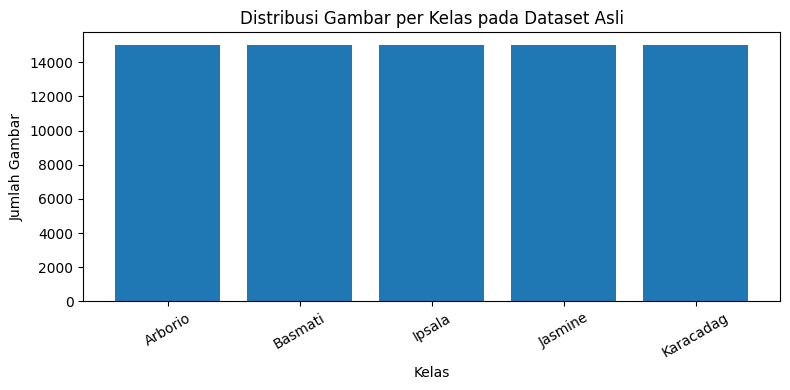

In [9]:
# Visualisasi distribusi kelas asli.
plt.figure(figsize=(8, 4))
plt.bar(eda_df["class_name"], eda_df["total_images"])
plt.title("Distribusi Gambar per Kelas pada Dataset Asli")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Data Preprocessing

In [10]:
MAX_IMAGES_PER_CLASS = 2500  # 2500 x 5 kelas = 12.500 gambar, tetap memenuhi saran >10.000 gambar.
IMG_SIZE = 96
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

all_image_paths = []
all_labels = []
label_to_index = {label: idx for idx, label in enumerate(class_names)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

for class_name in class_names:
    class_dir = DATA_ROOT / class_name
    image_paths = sorted([p for p in class_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS])
    random.Random(SEED).shuffle(image_paths)
    selected_paths = image_paths[:MAX_IMAGES_PER_CLASS]

    all_image_paths.extend([str(p) for p in selected_paths])
    all_labels.extend([label_to_index[class_name]] * len(selected_paths))

all_image_paths = np.array(all_image_paths)
all_labels = np.array(all_labels)

print("Total gambar yang dipakai:", len(all_image_paths))
print("Jumlah kelas:", num_classes)

subset_df = pd.DataFrame({"path": all_image_paths, "label": all_labels})
subset_df["class_name"] = subset_df["label"].map(index_to_label)
display(subset_df["class_name"].value_counts().sort_index().reset_index(name="total_images"))

Total gambar yang dipakai: 12500
Jumlah kelas: 5


,class_name,total_images
0,Arborio,2500
1,Basmati,2500
2,Ipsala,2500
3,Jasmine,2500
4,Karacadag,2500


#### Split Dataset

In [11]:
# Split train, validation, dan test secara stratified agar distribusi kelas tetap seimbang.
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=all_labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 8750
Validation: 1875
Test: 1875


In [12]:

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, label

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="data_augmentation")

def augment_image(image, label):
    image = data_augmentation(image, training=True)
    return image, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=min(len(paths), 3000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
test_ds = make_dataset(test_paths, test_labels, training=False)

print(train_ds)
print(val_ds)
print(test_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


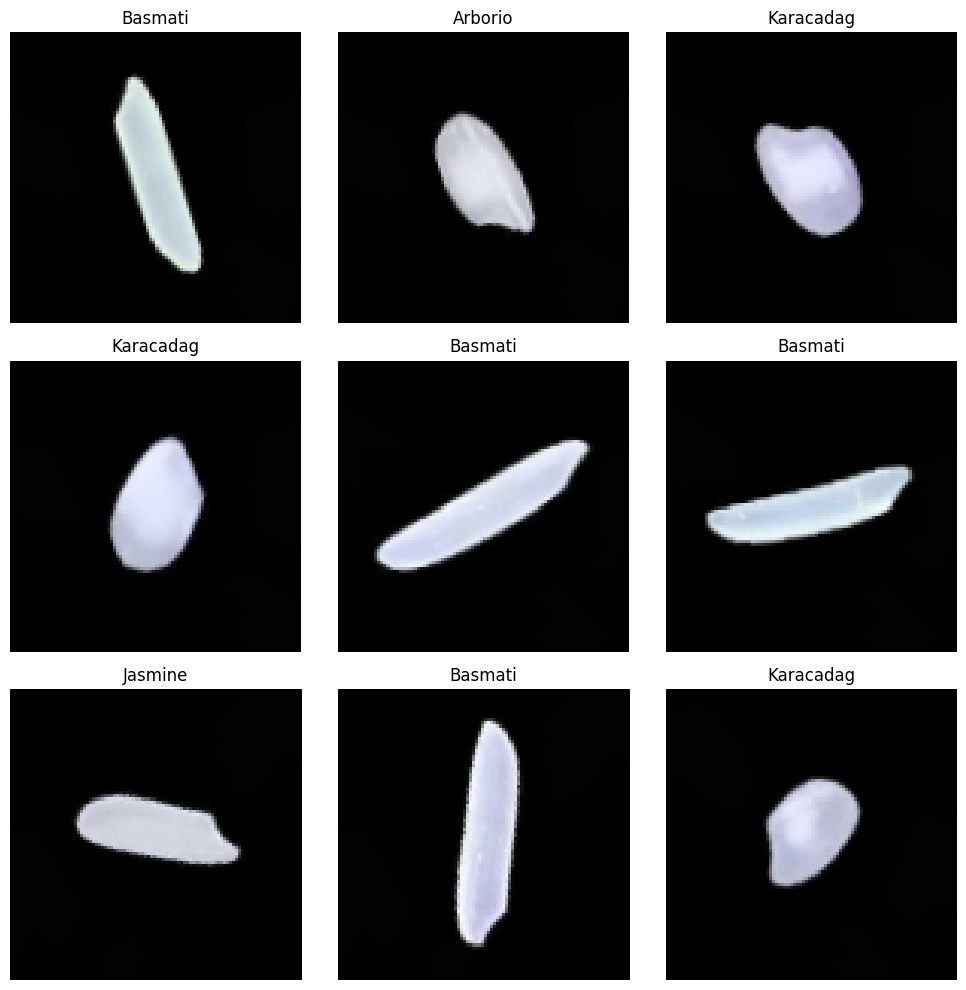

In [13]:
# Visualisasi beberapa gambar dari train set.
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.clip(images[i].numpy(), 0, 255).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

## Modelling

Model dibangun menggunakan `Sequential`, `Conv2D`, dan `MaxPooling2D` sesuai kriteria wajib. Layer data augmentation tidak dimasukkan ke dalam model utama agar proses export TF-Lite dan TFJS lebih stabil.

In [14]:
model = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
], name="rice_cnn_sequential")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "rice_cnn_sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,957 (1.61 MB)

 Trainable params: 421,957 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Callback untuk meningkatkan stabilitas training dan memenuhi saran nilai tinggi.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

EPOCHS = 40

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.3607 - loss: 1.3316
Epoch 1: val_accuracy improved from None to 0.51787, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - accuracy: 0.5645 - loss: 0.9657 - val_accuracy: 0.5179 - val_loss: 0.9630 - learning_rate: 0.0010
Epoch 2/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8892 - loss: 0.3094
Epoch 2: val_accuracy improved from 0.51787 to 0.92427, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step - accuracy: 0.9010 - loss: 0.2759 - val_accuracy: 0.9243 - val_loss: 0.2010 - learning_rate: 0.0010
Epoch 3/40
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9203 - loss: 0.2113
Epoch 3: val_accuracy did not improve from 0.92427
274/274 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9221 - loss: 0.2091 - val_accuracy: 0.9189 - val_loss: 0.2059 - 

## Evaluasi dan Visualisasi

In [16]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Testing Accuracy    : {test_acc:.4f}")
print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Testing Loss        : {test_loss:.4f}")

Training Accuracy   : 0.9699
Validation Accuracy : 0.9840
Testing Accuracy    : 0.9829
Training Loss       : 0.0829
Validation Loss     : 0.0513
Testing Loss        : 0.0509


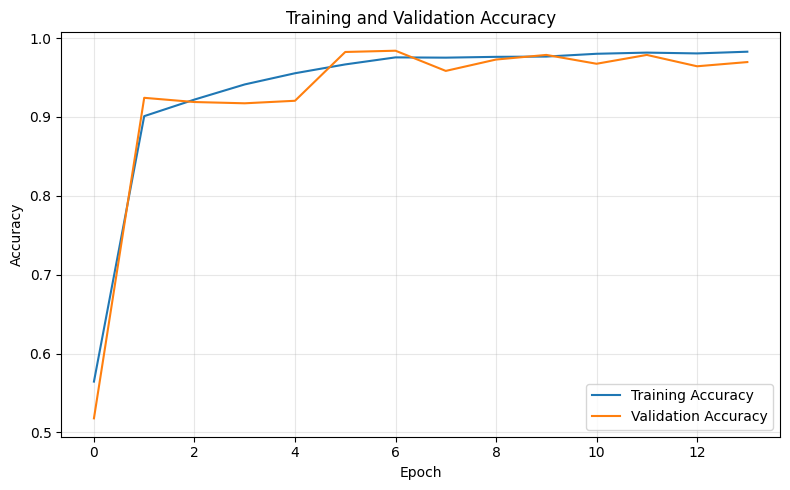

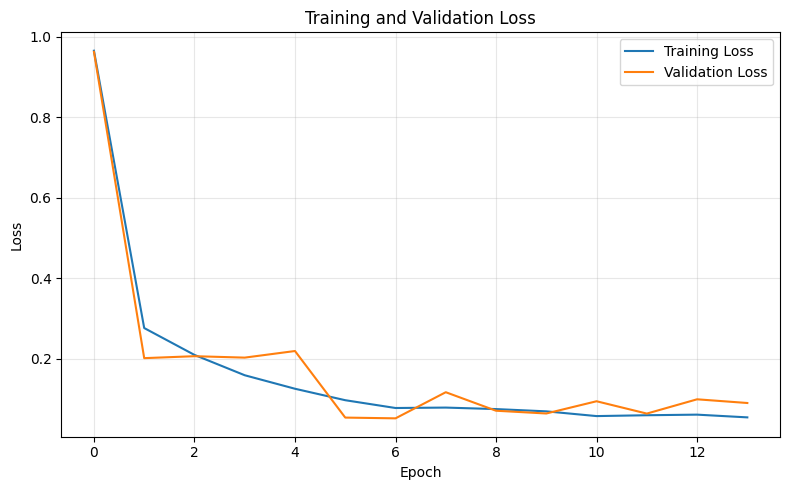

In [17]:
# Plot akurasi dan loss model.
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

     Arborio       0.99      0.96      0.98       375
     Basmati       0.98      0.98      0.98       375
      Ipsala       1.00      1.00      1.00       375
     Jasmine       0.97      0.98      0.98       375
   Karacadag       0.97      0.99      0.98       375

    accuracy                           0.98      1875
   macro avg       0.98      0.98      0.98      1875
weighted avg       0.98      0.98      0.98      1875



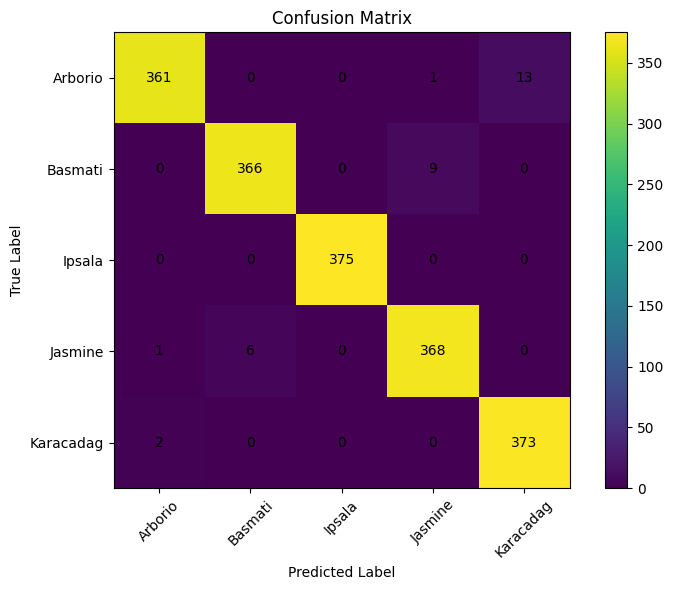

In [18]:
# Classification report dan confusion matrix pada test set.
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

## Konversi Model


In [19]:
# Struktur folder submission sesuai rekomendasi Dicoding.
os.makedirs("submission", exist_ok=True)
os.makedirs("submission/saved_model", exist_ok=True)
os.makedirs("submission/tflite", exist_ok=True)
os.makedirs("submission/tfjs_model", exist_ok=True)

saved_model_dir = "submission/saved_model"

if os.path.exists(saved_model_dir):
    shutil.rmtree(saved_model_dir)

# Keras 3 menggunakan export(), versi lama bisa menggunakan save(..., save_format="tf").
try:
    model.export(saved_model_dir)
except Exception as e:
    print("model.export gagal, mencoba model.save format SavedModel:", e)
    model.save(saved_model_dir, save_format="tf")

print("SavedModel tersimpan di:", saved_model_dir)
print(os.listdir(saved_model_dir))

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137429681648656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137429681649616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137429681650576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137429681649808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137429681650192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137429681651536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137429681651344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137429681648272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137429681650384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137429737603344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13742968

In [21]:
# Konversi ke TF-Lite.
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

tflite_model_path = "submission/tflite/model.tflite"
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)

with open("submission/tflite/label.txt", "w") as f:
    for label in class_names:
        f.write(label + "\n")

print("TF-Lite model saved to:", tflite_model_path)
print("TFLite folder:", os.listdir("submission/tflite"))

TF-Lite model saved to: submission/tflite/model.tflite
TFLite folder: ['label.txt', 'model.tflite']


In [22]:
# Konversi ke TensorFlow.js.
!pip -q install tensorflowjs


site_packages = Path("/usr/local/lib/python3.12/dist-packages")
tfjs_base = site_packages / "tensorflowjs"

for relative_file in ["read_weights.py", "write_weights.py"]:
    file_path = tfjs_base / relative_file
    if file_path.exists():
        text = file_path.read_text()
        text = text.replace("np.object", "object")
        text = text.replace("np.bool", "bool")
        file_path.write_text(text)
        print("Patched:", file_path)

# Patch tensorflow_hub jika environment tidak memiliki tf.compat.v1.estimator.
hub_estimator = site_packages / "tensorflow_hub" / "estimator.py"
if hub_estimator.exists():
    text = hub_estimator.read_text()
    text = text.replace("tf.compat.v1.estimator.Exporter", "object")
    hub_estimator.write_text(text)
    print("Patched:", hub_estimator)

tfjs_model_dir = "submission/tfjs_model"
if os.path.exists(tfjs_model_dir):
    shutil.rmtree(tfjs_model_dir)
os.makedirs(tfjs_model_dir, exist_ok=True)

!tensorflowjs_converter     --input_format=tf_saved_model     --output_format=tfjs_graph_model     submission/saved_model     submission/tfjs_model

print("TFJS folder:", os.listdir(tfjs_model_dir))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 821.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
db-dtypes 1.6.0 requires packaging>=24.2.0, but you have packaging 

In [23]:
# Validasi file hasil konversi.
print("SavedModel files:", os.listdir("submission/saved_model"))
print("TFLite files:", os.listdir("submission/tflite"))
print("TFJS files:", os.listdir("submission/tfjs_model"))

assert os.path.exists("submission/saved_model/saved_model.pb"), "saved_model.pb tidak ditemukan."
assert os.path.exists("submission/tflite/model.tflite"), "model.tflite tidak ditemukan."
assert os.path.exists("submission/tflite/label.txt"), "label.txt tidak ditemukan."
assert os.path.exists("submission/tfjs_model/model.json"), "model.json TFJS tidak ditemukan."
assert any(f.endswith(".bin") for f in os.listdir("submission/tfjs_model")), "file .bin TFJS tidak ditemukan."

print("Semua format model berhasil dibuat.")

SavedModel files: ['fingerprint.pb', 'saved_model.pb', 'variables', 'assets']
TFLite files: ['label.txt', 'model.tflite']
TFJS files: ['model.json', 'group1-shard1of1.bin']
Semua format model berhasil dibuat.


## Inference


True label     : Basmati
Predicted label: Basmati
Confidence     : 0.998855710029602


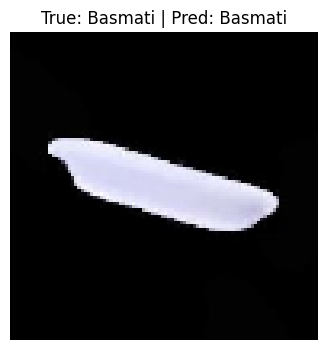

In [24]:
# Inference menggunakan model Keras.
for images, labels in test_ds.take(1):
    sample_image = images[0].numpy()
    true_label_index = int(labels[0].numpy())
    break

pred = model.predict(np.expand_dims(sample_image, axis=0), verbose=0)
predicted_index = int(np.argmax(pred[0]))
confidence = float(np.max(pred[0]))

print("True label     :", class_names[true_label_index])
print("Predicted label:", class_names[predicted_index])
print("Confidence     :", confidence)

plt.figure(figsize=(4, 4))
plt.imshow(np.clip(sample_image, 0, 255).astype("uint8"))
plt.title(f"True: {class_names[true_label_index]} | Pred: {class_names[predicted_index]}")
plt.axis("off")
plt.show()

In [25]:
# Inference menggunakan TF-Lite.
interpreter = tf.lite.Interpreter(model_path="submission/tflite/model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_data = np.expand_dims(sample_image, axis=0).astype(np.float32)
interpreter.set_tensor(input_details[0]["index"], input_data)
interpreter.invoke()

tflite_predictions = interpreter.get_tensor(output_details[0]["index"])
tflite_predicted_index = int(np.argmax(tflite_predictions[0]))
tflite_confidence = float(np.max(tflite_predictions[0]))

print("TF-Lite True label     :", class_names[true_label_index])
print("TF-Lite Predicted label:", class_names[tflite_predicted_index])
print("TF-Lite Confidence     :", tflite_confidence)

TF-Lite True label     : Basmati
TF-Lite Predicted label: Basmati
TF-Lite Confidence     : 0.9990212917327881


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [26]:
readme_text = f"""# Proyek Klasifikasi Gambar: Rice Image Dataset

Submission ini menggunakan Rice Image Dataset dari Kaggle.

## Dataset

- Source: Kaggle - muratkokludataset/rice-image-dataset
- Dataset asli: 75.000 gambar
- Jumlah kelas: 5
- Kelas: {', '.join(class_names)}
- Dataset yang digunakan pada notebook: {len(all_image_paths)} gambar
- Split: 70% train, 15% validation, 15% test

## Model

Model dibuat menggunakan TensorFlow/Keras dengan arsitektur Sequential CNN.
Model memenuhi kriteria penggunaan Sequential, Conv2D, dan MaxPooling2D.

## Hasil Evaluasi

- Training Accuracy: {train_acc:.4f}
- Validation Accuracy: {val_acc:.4f}
- Testing Accuracy: {test_acc:.4f}

## Format Model

Folder submission berisi:

- saved_model/
- tflite/model.tflite
- tflite/label.txt
- tfjs_model/model.json
- tfjs_model/group1-shard*.bin
- README.md
- requirements.txt

## Inference

Notebook sudah menyertakan contoh inference menggunakan model Keras dan TF-Lite.
"""

with open("submission/README.md", "w") as f:
    f.write(readme_text)

requirements_text = """tensorflow
numpy
pandas
matplotlib
scikit-learn
Pillow
kaggle
tensorflowjs
"""

with open("submission/requirements.txt", "w") as f:
    f.write(requirements_text)

print("README.md dan requirements.txt berhasil dibuat.")
print(os.listdir("submission"))

README.md dan requirements.txt berhasil dibuat.
['README.md', 'tfjs_model', 'requirements.txt', 'tflite', 'saved_model']


In [27]:
# Zip folder submission.
# Penting: setelah notebook selesai dijalankan, download notebook .ipynb dari Colab,
# lalu masukkan file tersebut ke dalam folder submission sebagai notebook.ipynb sebelum submit ke Dicoding.

zip_path = "submission_rice_image_classification.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive("submission_rice_image_classification", "zip", "submission")

print("ZIP dibuat:", zip_path)
print("Jangan lupa masukkan notebook .ipynb yang sudah dijalankan ke dalam ZIP final sebagai notebook.ipynb.")

ZIP dibuat: submission_rice_image_classification.zip
Jangan lupa masukkan notebook .ipynb yang sudah dijalankan ke dalam ZIP final sebagai notebook.ipynb.
